# Final General Anxiety Disorder (GAD) data analysis
The NHIS data was collected by the CDC in America and the gaming data was primarily provided by 18-22 year olds, so the comparisons below follow those guidelines for a more equal comparison.

In [45]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
# import matplotlib.patches
import numpy as np
import seaborn as sns
from my_functions import visualize_count_plot, visualize_and_label_count_plot

conn = sqlite3.connect('../data/mentalhealth.db')

pd.set_option('display.max_columns', None)

## Set Global Variables

In [2]:
colors_ld=['#92c5de','#4393c3', '#2166ac', '#5e3c99', '#2d1e2f', '#0f0a14']
colors_dl=['#0f0a14', '#2d1e2f', '#5e3c99', '#2166ac', '#4393c3', '#92c5de']

### Temporary View of all GAD Data

In [3]:
conn.execute("""
    CREATE TEMP VIEW gad_data_usa_18_22 AS
    SELECT
        p.participant_id,
        p.survey_id,
        p.sex_id,
        p.education_id,
        p.residence,
        p.age,
        p.region_id,
        r.GAD1,
        r.GAD2,
        r.GAD3,
        r.GAD4,
        r.GAD5,
        r.GAD6,
        r.GAD7,
        r.GAD_total,
        r.GAD_cat
    FROM participant p
    JOIN GAD_response r on r.participant_id = p.participant_id
    WHERE (p.age BETWEEN 18 AND 22)
        AND p.residence = 'USA'
""")

## How do the total GAD scores compare between gamers and the general population?

### GAD Scores Queries

In [4]:
gamer_GAD_scores_query = ("""
    SELECT
        g.GAD_total,
        g.GAD_cat,
        c.cat_name
    FROM gad_data_usa_18_22 g
    JOIN GAD_category c on c.GAD_cat = g.GAD_cat
    WHERE survey_id = 1
""")

gamer_GAD_scores_result = pd.read_sql(gamer_GAD_scores_query, conn)


nhis_GAD_scores_query = ("""
    SELECT
        g.GAD_total,
        g.GAD_cat,
        c.cat_name
    FROM gad_data_usa_18_22 g
    JOIN GAD_category c on c.GAD_cat = g.GAD_cat
    WHERE survey_id = 2
""")

nhis_GAD_scores_result = pd.read_sql(nhis_GAD_scores_query, conn)

all_GAD_scores_query = ("""
    SELECT
        g.GAD_total,
        g.GAD_cat,
        c.cat_name,
        g.survey_id
    FROM gad_data_usa_18_22 g
    JOIN GAD_category c on c.GAD_cat = g.GAD_cat
""")

all_GAD_scores_result = pd.read_sql(all_GAD_scores_query, conn)
all_GAD_scores_result

,GAD_total,GAD_cat,cat_name,survey_id
0,19,4,Severe (>15),1
1,0,1,None/Minimal (0-4),1
2,3,1,None/Minimal (0-4),1
3,4,1,None/Minimal (0-4),1
4,1,1,None/Minimal (0-4),1
...,...,...,...,...
4797,2,1,None/Minimal (0-4),2
4798,0,1,None/Minimal (0-4),2
4799,6,2,Mild (5-9),2
4800,15,4,Severe (>15),2


### Countplot Function

In [5]:
# ===============================
# ADD LABELS WITH NAME OF STUDY!
# ===============================



def display_GAD_countplot(dataframe, label_y_align, plot_title):

    average_GAD = dataframe['GAD_total'].mean().round(1)

    plt.figure(figsize=(10,6))

    # This tells the palette how the categories should be colored
    palette_list = {
        'None/Minimal (0-4)': colors_ld[0],
        'Mild (5-9)': colors_ld[1],
        'Moderate (10-14)': colors_ld[2],
        'Severe (>15)': colors_ld[3]
    }

    ax = sns.countplot(
        x='GAD_total', 
        data = dataframe,
        hue = 'cat_name', 
            # hue tells the palette what column to use to know 
            # what category to use from the palette_list
        dodge=False,
        gap=-.25,
        palette = palette_list,
        edgecolor=colors_ld[-1]
    )

    # Remove extra lines
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Add average line
    ax.axvline(
        average_GAD,
        color="red",
        linewidth = 1,
        alpha = .7
    )

    ax.text(
        average_GAD+0.25,
        label_y_align,
        f"Avearage\nGAD score\n({average_GAD})",
        color="red",
        fontsize=10
    )

    # Customize xticks
    plt.xticks([0, 10, 20], [0, 10, 20])


    plt.legend(
        title='Anxiety Level', 
        loc='center right'
        )

    plt.title(plot_title, fontsize=18, pad=20)
    plt.xlabel("Generalized Anxiety Disorder (GAD) Assessment Score", fontsize=12)
    plt.ylabel("Number of Survey Participants", fontsize=12)

    plt.tight_layout()

    plt.show()

# References: 
#   1- https://stackoverflow.com/questions/59695334/custom-color-palette-in-seaborn
#   2- I got very close, but needed help understanding how 'hue', 'dodge', and 'gap'worked: ChatGPT helped
#   3- https://www.geeksforgeeks.org/python/how-to-adjust-number-of-ticks-in-seaborn-plots/ 

### GAD Score Visualizations

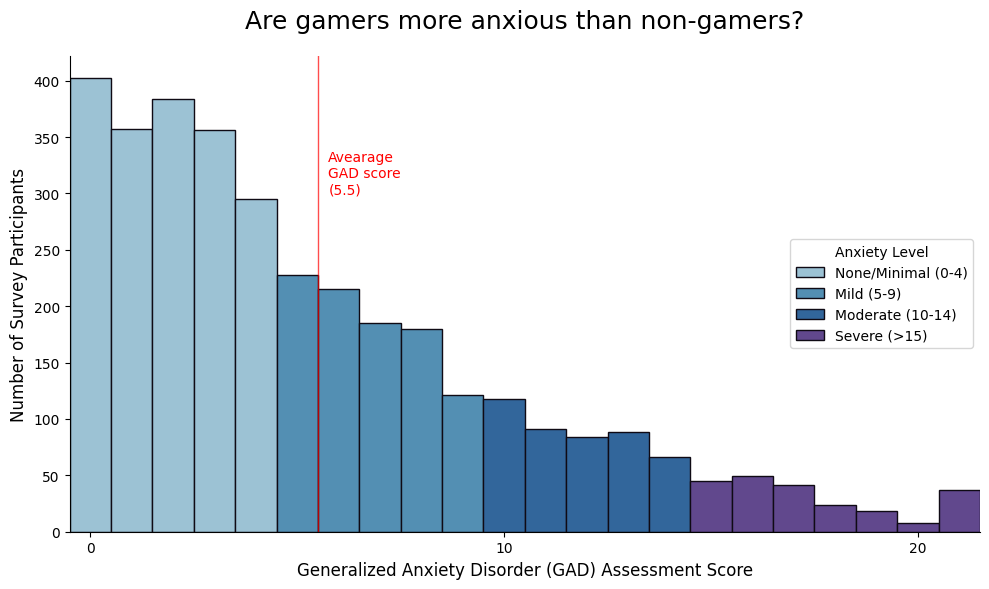

In [6]:
display_GAD_countplot(gamer_GAD_scores_result, 300, 'Are gamers more anxious than non-gamers?')

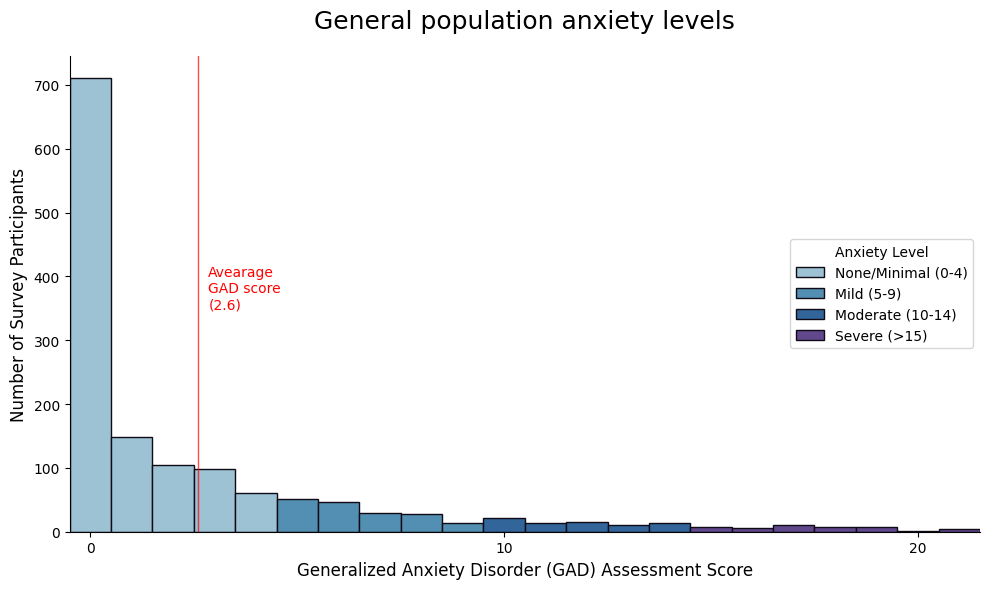

In [7]:
display_GAD_countplot(nhis_GAD_scores_result, 350, 'General population anxiety levels')

#### Display the above plots next to each other?

In [8]:
# =================
# I will return to this; 
# I will need to use percentages 
# rather than totals.
# =================

# g = sns.FacetGrid(all_GAD_scores_result)
# g.map_dataframe(display_GAD_countplot(all_GAD_scores_result, 350, 'General population anxiety levels'))

# References:
#   https://www.youtube.com/watch?v=-esRf38TqkI

## How did the GAD categorizations compare between gamers and the general population?

### GAD Categories by Percentage Queries

In [9]:
gamer_GAD_cat_percentages_query =("""
    SELECT
        g.GAD_cat,
        c.cat_name,
        COUNT(*) AS sum_participants,
        COUNT(*) * 100.0 / SUM(COUNT(*)) OVER () AS percentage
    FROM gad_data_usa_18_22 g
    JOIN GAD_category c on c.GAD_cat = g.GAD_cat
    WHERE survey_id = 1
    GROUP BY g.GAD_cat
    ORDER BY g.GAD_cat
""")

gamer_GAD_cat_percentages_response = pd.read_sql(gamer_GAD_cat_percentages_query, conn)
gamer_GAD_cat_percent_series = pd.read_sql(gamer_GAD_cat_percentages_query, conn, index_col='cat_name')['percentage']


nhis_GAD_cat_percentages_query =("""
    SELECT
        g.GAD_cat,
        c.cat_name,
        COUNT(*) AS sum_participants,
        COUNT(*) * 100.0 / SUM(COUNT(*)) OVER () AS percentage
    FROM gad_data_usa_18_22 g
    JOIN GAD_category c on c.GAD_cat = g.GAD_cat
    WHERE survey_id = 2
    GROUP BY g.GAD_cat
    ORDER BY g.GAD_cat
""")

nhis_GAD_cat_percentages_response = pd.read_sql(nhis_GAD_cat_percentages_query, conn)
nhis_GAD_cat_percent_series = pd.read_sql(nhis_GAD_cat_percentages_query, conn, index_col='cat_name')['percentage']

### Pie Chart Function

In [10]:
def display_GAD_pie_chart (series_name, plot_name):
    fig, ax = plt.subplots(figsize=(8,8))

    ax.pie(
        series_name,
        # labels=None,
        # startangle=110,
        colors = colors_ld,
        # labels=series_name.index,
        autopct='%1.1f%%',
        # pctdistance=.75,
        # labeldistance=.5
        )

    ax.set_title(plot_name)

    ax.legend(
        labels = series_name.index,
        loc="lower right",
        title = "Platform"
    )

    plt.tight_layout()
    plt.show()

# Reference(s):
#   https://matplotlib.org/stable/gallery/pie_and_polar_charts/pie_features.html

### GAD Categorization Visualizations

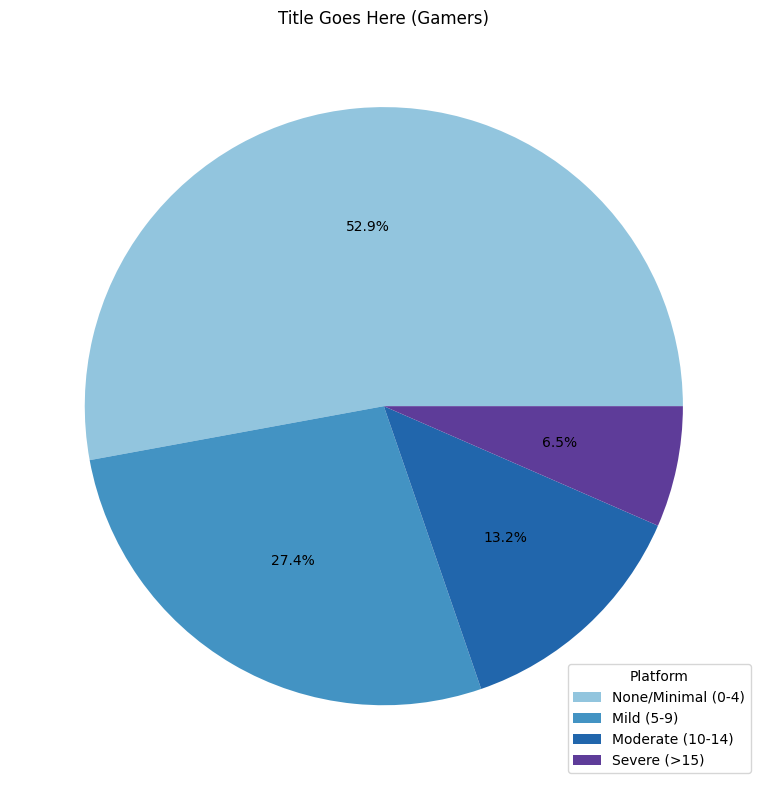

In [11]:
display_GAD_pie_chart(gamer_GAD_cat_percent_series, 'Title Goes Here (Gamers)')

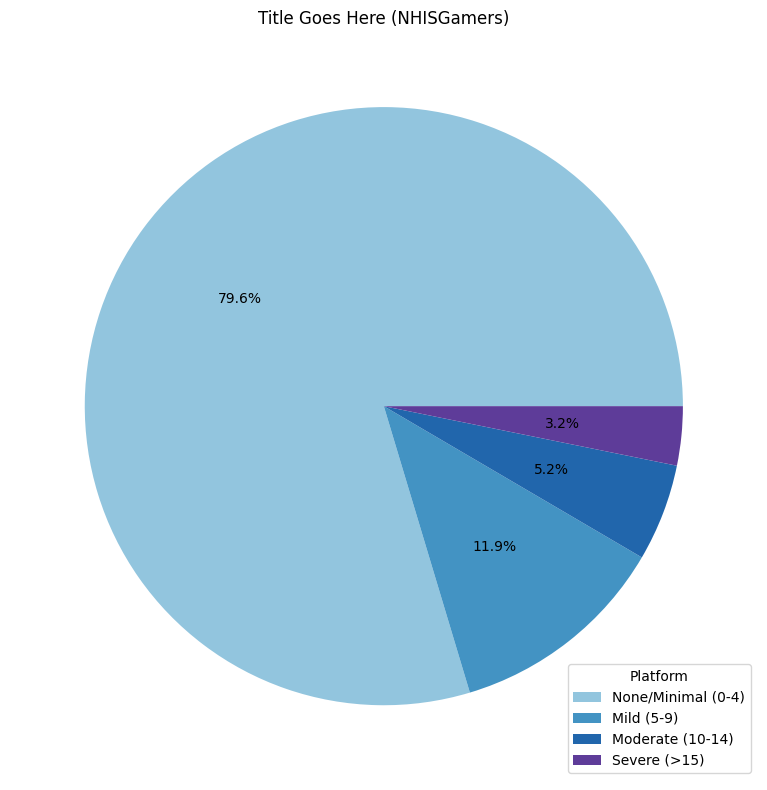

In [12]:
display_GAD_pie_chart(nhis_GAD_cat_percent_series, 'Title Goes Here (NHISGamers)')

## Did hours spent gaming impact participant's GAD score?
- This will use just the gaming data. (Keeping 18-22 year olds in USA)
- Histogram, Scatterplot, or Count Plot

### Gaming Hours and GAD Score Query

In [13]:
hours_GAD_scores_query = ("""
    SELECT
        p.participant_id,
        gad.GAD_total,
        game.hours
    FROM participant p
    JOIN GAD_response gad on gad.participant_id = p.participant_id
    JOIN gaming_response game on game.participant_id = p.participant_id
    WHERE p.survey_id = 1
        AND p.residence = 'USA'
""")

hours_GAD_scores_response = pd.read_sql(hours_GAD_scores_query, conn)

### Gaming Hours Visualization

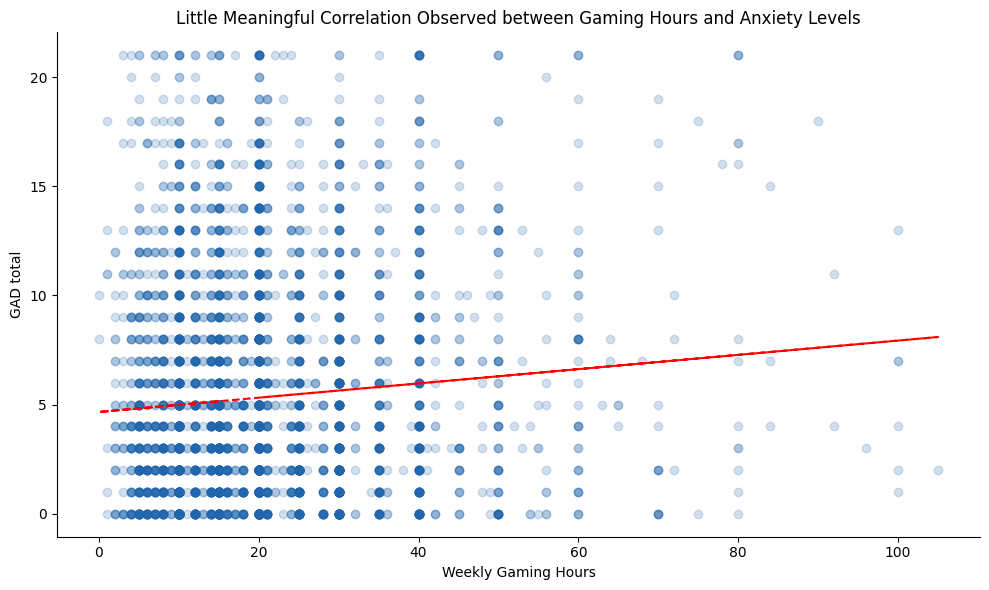

In [25]:
plt.figure(figsize=(10, 6))
plt.scatter(
    hours_GAD_scores_response['hours'], 
    hours_GAD_scores_response['GAD_total'],
    color = colors_dl[3],
    alpha = 0.2,
    # s = 25 # changes plot size
    )

plt.xlabel('Weekly Gaming Hours')
plt.ylabel('GAD total')
plt.title('Little Meaningful Correlation Observed between Gaming Hours and Anxiety Levels')

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Draw trend line
x = hours_GAD_scores_response['hours']
y = hours_GAD_scores_response['GAD_total']
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(x, p(x), 'r--')


plt.tight_layout()
plt.show()

# Reference(s):
#   https://stackoverflow.com/questions/41635448/how-can-i-draw-scatter-trend-line


## How did gaming platform impact participant's GAD score/category?
- This will use just the gaming data.
- Box plots

### Gaming Platform and GAD Score Query

In [32]:
# Query here
# platform, score

platform_GAD_query = ("""
    SELECT
        gad.GAD_total,
        gr.platform
    FROM participant p
    JOIN GAD_response gad on gad.participant_id = p.participant_id
    JOIN gaming_response gr on gr.participant_id = p.participant_id
    WHERE p.survey_id = 1
        AND (p.age BETWEEN 18 AND 22)
        AND p.residence = 'USA'
""")

platform_GAD_response = pd.read_sql(platform_GAD_query, conn)
platform_GAD_response

,GAD_total,platform
0,19,PC
1,0,PC
2,3,"Console (PS, Xbox, ...)"
3,4,"Console (PS, Xbox, ...)"
4,1,PC
...,...,...
3387,1,PC
3388,11,PC
3389,2,PC
3390,6,PC


### Gaming Platform and GAD Score Visualization

In [33]:
platform_GAD_response['platform'].unique()

<StringArray>
['PC', 'Console (PS, Xbox, ...)', 'Smartphone / Tablet']
Length: 3, dtype: str

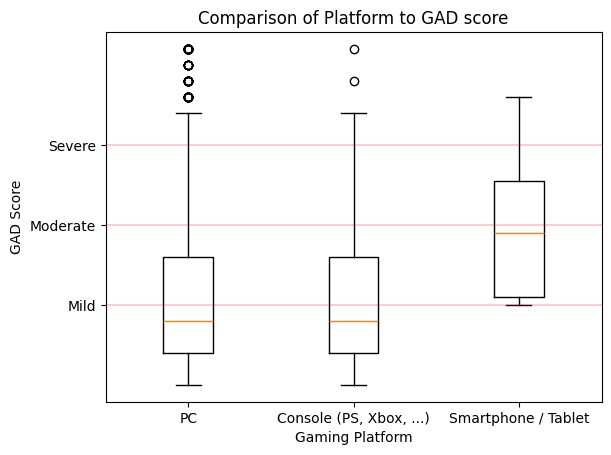

In [44]:
plt.boxplot(
    [platform_GAD_response[platform_GAD_response['platform'] == 'PC']['GAD_total'],
    platform_GAD_response[platform_GAD_response['platform'] == 'Console (PS, Xbox, ...)']['GAD_total'],
    platform_GAD_response[platform_GAD_response['platform'] == 'Smartphone / Tablet']['GAD_total']
    ],
    tick_labels=['PC', 'Console (PS, Xbox, ...)', 'Smartphone / Tablet']
)

plt.yticks(ticks=[5,10, 15],
            labels=['Mild', 'Moderate', 'Severe'])
plt.axhline(y=5, color='r', linestyle='-', alpha = 0.2)
plt.axhline(y=10, color='r', linestyle='-', alpha = 0.2)
plt.axhline(y=15, color='r', linestyle='-', alpha = 0.2)

plt.xlabel('Gaming Platform')
plt.ylabel('GAD Score')
plt.title('Comparison of Platform to GAD score')

plt.show()

# Conclusion(s)